In [152]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [151]:
def plot_vs_x(
    df,
    x_col,
    y_cols,
    err_cols=None,
    y_labels=None,
    group_col="beam_type",
    groups=("col", "uncol"),
    markers=("o", "s"),
    min_vals=None,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=(8, 5),
):
    if isinstance(y_cols, str):
        y_cols = [y_cols]
    if err_cols is None:
        err_cols = [None] * len(y_cols)
    elif isinstance(err_cols, str):
        err_cols = [err_cols]
    if y_labels is None:
        y_labels = y_cols
    if min_vals is None:
        min_vals = [None] * len(y_cols)
    elif not isinstance(min_vals, (list, tuple)):
        min_vals = [min_vals] * len(y_cols)

    # NEW: no grouping -> single pass over the whole dataframe
    if group_col is None:
        groups = [None]

    plt.figure(figsize=figsize)

    for group in groups:
        sub = df if group is None else df[df[group_col] == group]

        for y_col, err_col, y_label, marker, min_val in zip(
            y_cols, err_cols, y_labels, markers, min_vals
        ):
            plot_data = sub if min_val is None else sub[sub[y_col] > min_val]

            yerr = plot_data[err_col] if err_col is not None else None
            label = y_label if group is None else f"{group} {y_label}"
            plt.errorbar(
                plot_data[x_col], plot_data[y_col],
                yerr=yerr,
                marker=marker, capsize=4, linestyle="--",
                label=label
            )

    plt.xlabel(xlabel or x_col.capitalize())
    plt.ylabel(ylabel or "")
    plt.title(title or f"Evolution with {x_col}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [143]:
kind = "YAG"
# Load CSV

if kind == "YAG":
    df = pd.read_csv("CLEAR_experiments/May2026/PDD_YAG_large_orig.csv")

    # Extract type: col or uncol
    df["beam_type"] = df["folder"].apply(
        lambda x: "uncol" if "uncol" in x else "col"
)

    # Keep only the standard depth points
    # Remove this line if you also want the _M and _after rows
    # df = df[~df["folder"].str.contains(r"_M|_after", regex=True)].copy()

    # Beam type
    df["beam_type"] = df["folder"].apply(lambda x: "uncol" if "uncol" in x else "col")
    # Extract depth number from folder name
    # df["depth"] = df["folder"].str.extract(r"_(?:col|uncol)_(\d+)").astype(float)
    df["depth"] = df["folder"].str.extract(r"(\d+)").astype(float)
    df['depth'] = df['depth']-25 # Convert to actual depth
    df["magnet"] = df["folder"].str.extract(r"_(?:col|uncol)_(\d+)").astype(float)
    
elif kind == "RCF":
    df = pd.read_csv("CLEAR_experiments/May2026/13_05_2026film_parameters.csv").copy()
    # Extract film number, e.g. G_001 -> 1
    df["film_num"] = df["film"].str.extract(r"(\d+)").astype(int)

    # Sort by film number so the block mapping is correct
    df = df.sort_values("film_num").reset_index(drop=True)

    # Depths for the 5 blocks
    depth_map = [45, 134, 163, 222, 281]

    # Each depth has 4 entries:
    # 1,2,3 -> uncol
    # 4     -> col
    block_size = 4
    df["depth_block"] = (df["film_num"] - 1) // block_size
    df["repeat_in_block"] = (df["film_num"] - 1) % block_size + 1

    df["beam_type"] = df["repeat_in_block"].apply(
        lambda n: "col" if n == 4 else "uncol"
    )

    df["depth"] = df["depth_block"].apply(
        lambda i: depth_map[i] if i < len(depth_map) else pd.NA
    )

    # Drop rows beyond the mapped depths
    df = df.dropna(subset=["depth"]).copy()
    df["depth"] = df["depth"].astype(float)
    df['depth'] = df['depth']-25 # Convert to actual depth

else:
    raise ValueError("kind must be 'YAG' or 'RCF'")


# Sort for cleaner line plots
df = df.sort_values(["beam_type", "depth"])
df



,folder,cx,cy,P_x,P_y,CD_centre,r90_x,r90_y,ratio_x,ratio_y,CD_std,errPx,errPy,err_x90_x,err_x90_y,charge_after_bgnd_pC,beam_type,depth,magnet
9,FLASH_multi_45mm_col_aligned,434,631,1.730129,1.879572,18.536498,3.454211,3.557649,1.032672,1.085311,0.321594,0.011494,0.012711,0.015740,0.015252,3.521468,col,20.0,NaN
21,FLASH_single_45mm_col,437,423,1.484177,1.617595,0.328337,2.944309,3.102912,0.958121,1.038491,0.022700,0.015778,0.013850,0.024994,0.019451,0.058100,col,20.0,NaN
11,FLASH_multi_65mm_col_aligned,429,620,1.544609,1.602684,18.117418,3.193734,3.218466,0.988800,1.019208,0.301792,0.009848,0.009665,0.015637,0.014415,3.512321,col,40.0,NaN
22,FLASH_single_65mm_col,437,422,1.333495,1.422576,0.313182,2.728798,2.826379,0.901687,0.968644,0.021585,0.013875,0.010285,0.025228,0.017004,0.058023,col,40.0,NaN
24,FLASH_single_85mm_col,441,418,1.180972,1.253493,0.299902,2.505266,2.564356,0.802288,0.870412,0.018930,0.011633,0.007270,0.024753,0.014042,0.059244,col,60.0,NaN
0,FLASH_multi_105mm_col_aligned,442,627,1.113075,1.080890,15.155725,2.662382,2.501104,0.725120,0.690779,0.315669,0.009401,0.008499,0.024023,0.022096,3.527320,col,80.0,NaN
13,FLASH_single_105mm_col,454,418,1.001290,1.083623,0.265351,2.252736,2.263549,0.016654,0.642084,0.016941,0.011598,0.006679,0.030951,0.015226,0.057759,col,80.0,NaN
2,FLASH_multi_155mm_col_aligned,454,623,1.000000,1.000000,11.439394,2.857184,2.693011,0.010585,0.005734,0.316972,0.013871,0.008906,0.049008,0.030498,3.548650,col,130.0,NaN
15,FLASH_single_155mm_col,468,377,1.000000,1.000000,0.160458,2.654726,2.535546,0.009813,0.004638,0.013011,0.021649,0.018726,0.070238,0.057348,0.058430,col,130.0,NaN
4,FLASH_multi_205mm_col_aligned,471,633,1.000000,1.000000,8.922353,3.312575,3.318834,0.010932,0.009110,0.347989,0.017897,0.011797,0.079084,0.057250,3.594257,col,180.0,NaN


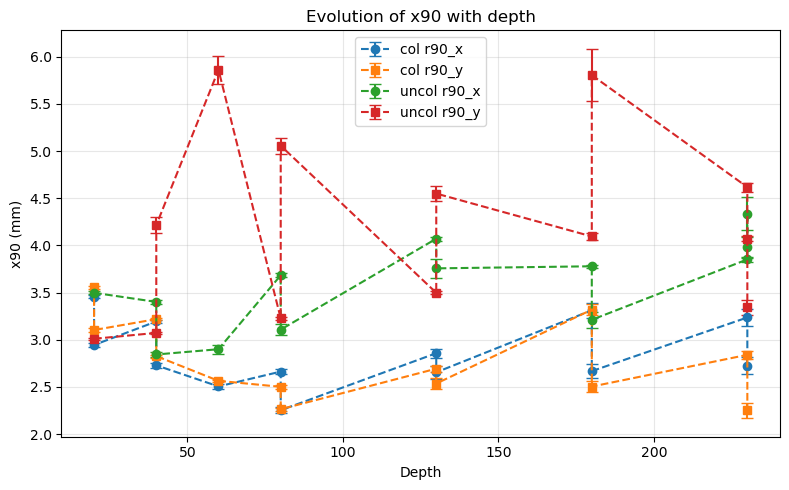

In [ ]:
# -------------------------
# Plot 1: r90_x and r90_y
# -------------------------

plot_vs_x(df, group_col="beam_type",
    groups=("col", "uncol"),
    markers=("o", "s"),x_col="depth", y_cols=["r90_x", "r90_y"], err_cols=["err_x90_x", "err_x90_y"], y_labels=["r90_x", "r90_y"], xlabel="Depth", ylabel="x90 (mm)", title="Evolution of x90 with depth")

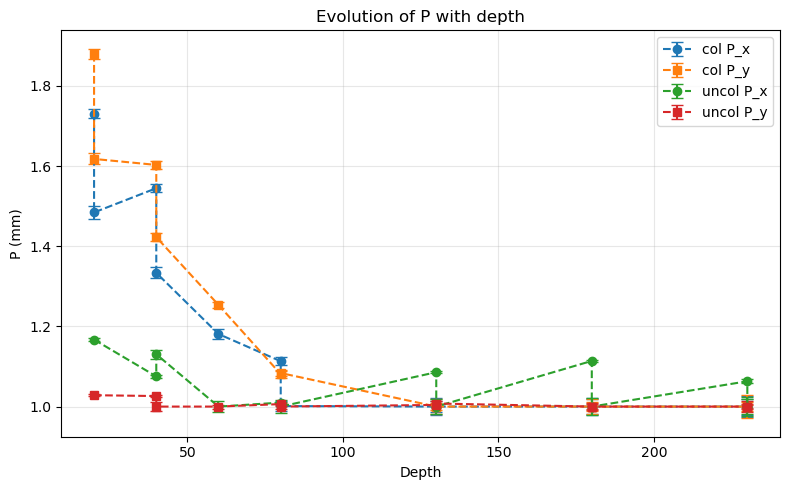

In [146]:
# -------------------------
# Plot 2: P_x and P_y
# -------------------------
plot_vs_x(
    df, x_col="depth",
    y_cols=["P_x", "P_y"],
    err_cols=["errPx", "errPy"],
    ylabel="P (mm)",
    title="Evolution of P with depth"
)

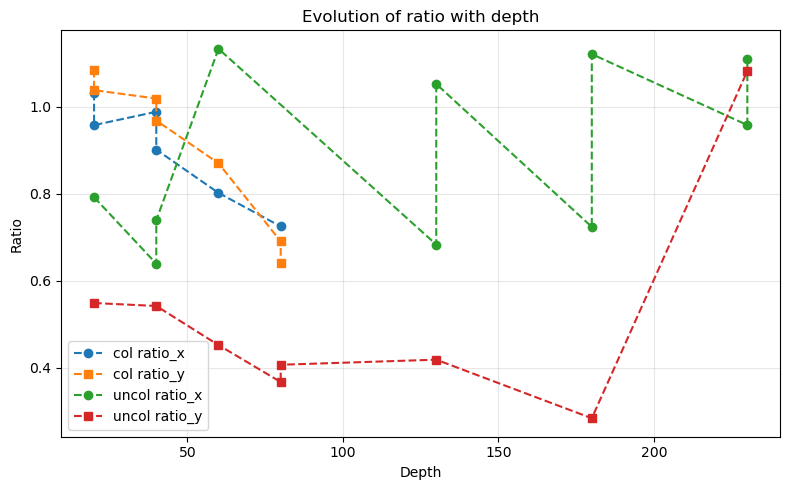

In [149]:
# -------------------------
# Plot 3: ratio_x and ratio_y
# -------------------------
plot_vs_x(
    df, x_col="depth",
    y_cols=["ratio_x", "ratio_y"],
    err_cols=None,
    min_vals=[0.1, 0.1],
    ylabel="Ratio",
    title="Evolution of ratio with depth"
)

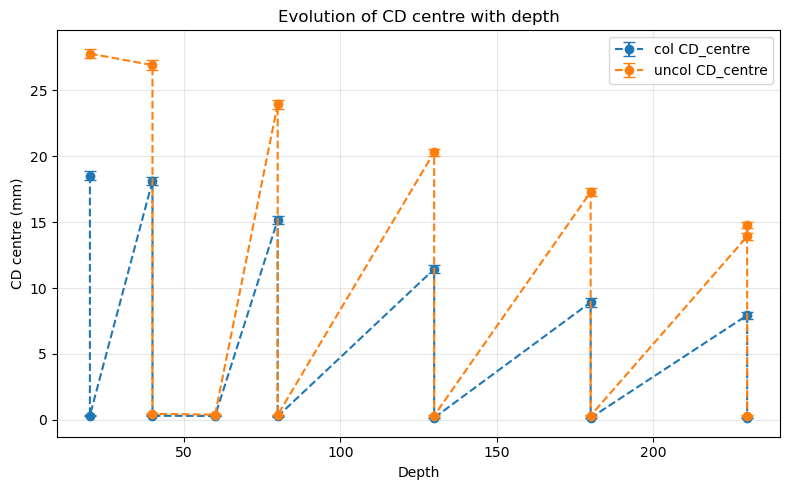

In [150]:
# -------------------------
# Plot 4: dose
# -------------------------
plot_vs_x(
    df, x_col="depth",
    y_cols="CD_centre",
    err_cols="CD_std",
    ylabel="CD centre (mm)",
    title="Evolution of CD centre with depth"
)